### Notebook 01: Análise Exploratória de Dados (EDA)

#### Projeto Semantix - Segmentação de Clientes

In [1]:
# %% [markdown]
# # Projeto Semantix - Segmentação de Clientes
# ## Análise Exploratória de Dados (EDA)
# 
# **Objetivo:** Compreender a estrutura dos dados, identificar padrões iniciais e preparar para a engenharia de features.
# 
# **Dataset:** Online Retail (UCI) - Transações de uma varejista online do Reino Unido
# **Período:** 01/12/2010 a 09/12/2011

# %% [markdown]
# ### 1. Importação das Bibliotecas

# %%
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Utilitários
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style="whitegrid")

print("✅ Bibliotecas importadas com sucesso!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Seaborn version: {sns.__version__}")

✅ Bibliotecas importadas com sucesso!
Pandas version: 2.3.3
NumPy version: 2.2.6
Seaborn version: 0.13.2


In [ ]:
# %% [markdown]
# ### 2. Carregamento dos Dados

# %%
# URL do dataset Online Retail da UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

print("📥 Baixando dados...")
df = pd.read_excel(url)

print(f"✅ Dados carregados com sucesso!")
print(f"📊 Shape do dataset: {df.shape}")
print(f"📅 Período dos dados: {df['InvoiceDate'].min()} a {df['InvoiceDate'].max()}")

📥 Baixando dados...
✅ Dados carregados com sucesso!
📊 Shape do dataset: (541909, 8)
📅 Período dos dados: 2010-12-01 08:26:00 a 2011-12-09 12:50:00


In [3]:
# %% [markdown]
# ### 3. Primeira Visualização dos Dados

# %%
# Visualizar as primeiras linhas
print("🔍 Primeiras 5 linhas:")
display(df.head())

# %%
# Visualizar as últimas linhas
print("🔍 Últimas 5 linhas:")
display(df.tail())

🔍 Primeiras 5 linhas:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom


🔍 Últimas 5 linhas:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.00,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.00,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.00,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.00,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.00,France


In [4]:
# %% [markdown]
# ### 4. Informações Gerais do Dataset

# %%
# Informações do DataFrame
print("ℹ️ Informações do dataset:")
df.info()

# %%
# Estatísticas descritivas básicas
print("📈 Estatísticas descritivas das variáveis numéricas:")
display(df.describe())

# %%
# Estatísticas descritivas das variáveis categóricas
print("📊 Estatísticas das variáveis categóricas:")
display(df.describe(include=['object']))

ℹ️ Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
📈 Estatísticas descritivas das variáveis numéricas:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.00,541909,541909.00,406829.00
mean,9.55,2011-07-04 13:34:57.156386048,4.61,15287.69
min,-80995.00,2010-12-01 08:26:00,-11062.06,12346.00
25%,1.00,2011-03-28 11:34:00,1.25,13953.00
50%,3.00,2011-07-19 17:17:00,2.08,15152.00
75%,10.00,2011-10-19 11:27:00,4.13,16791.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,218.08,NaN,96.76,1713.60


📊 Estatísticas das variáveis categóricas:


,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


🔍 Análise de valores faltantes:


,Valores Faltantes,Percentual (%)
CustomerID,135080,24.93
Description,1454,0.27


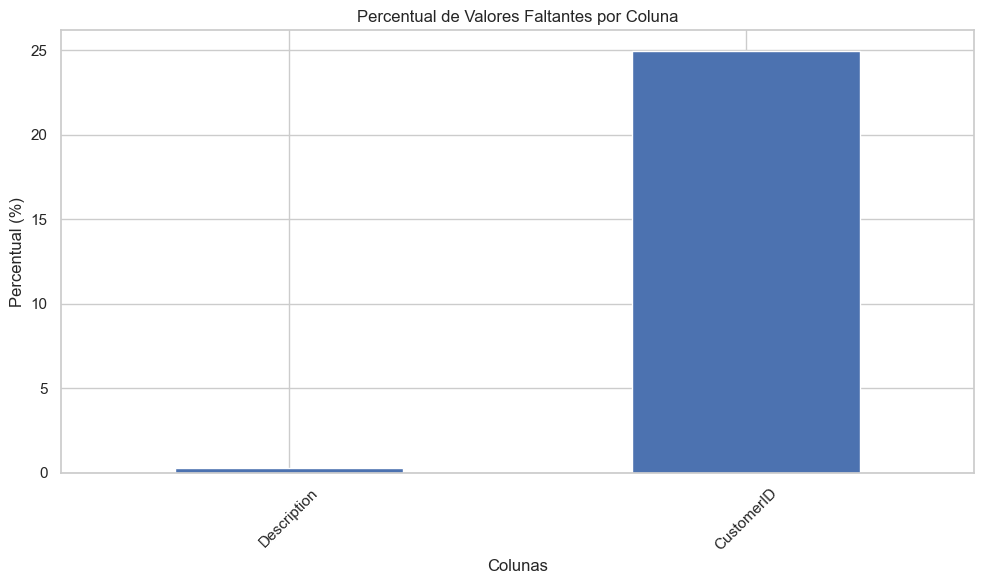

In [5]:
# %% [markdown]
# ### 5. Análise de Valores Faltantes

# %%
# Verificar valores nulos
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Valores Faltantes': missing_data,
    'Percentual (%)': missing_percent
}).sort_values(by='Valores Faltantes', ascending=False)

print("🔍 Análise de valores faltantes:")
display(missing_df[missing_df['Valores Faltantes'] > 0])

# %%
# Visualização dos valores faltantes
plt.figure(figsize=(10, 6))
missing_percent[missing_percent > 0].plot(kind='bar')
plt.title('Percentual de Valores Faltantes por Coluna')
plt.xlabel('Colunas')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [6]:
# %% [markdown]
# ### 6. Análise da Variável 'CustomerID'
# 
# `CustomerID` é fundamental para segmentação. Vamos entender os registros sem identificação.

# %%
# Clientes sem identificação
df_sem_customer = df[df['CustomerID'].isna()]
print(f"📊 Registros sem CustomerID: {len(df_sem_customer)} ({len(df_sem_customer)/len(df)*100:.2f}%)")

# %%
# Análise das transações sem CustomerID
print("🎯 Análise das transações sem identificação de cliente:")
print(f"- Quantidade total: {df_sem_customer['Quantity'].sum():,.0f}")
print(f"- Valor total: £{df_sem_customer['Quantity'].sum() * df_sem_customer['UnitPrice'].mean():,.2f}")
print(f"- Ticket médio: £{(df_sem_customer['Quantity'] * df_sem_customer['UnitPrice']).mean():,.2f}")

# %%
# Decisão: Remover registros sem CustomerID (não podemos segmentar sem identificar o cliente)
print("⚠️ Decisão: Remover registros sem CustomerID para análise de clientes")
df_clean = df.dropna(subset=['CustomerID']).copy()
print(f"📊 Shape após remoção: {df_clean.shape}")
print(f"✅ Registros mantidos: {len(df_clean)} ({len(df_clean)/len(df)*100:.2f}%)")

📊 Registros sem CustomerID: 135080 (24.93%)
🎯 Análise das transações sem identificação de cliente:
- Quantidade total: 269,562
- Valor total: £2,177,138.23
- Ticket médio: £10.72
⚠️ Decisão: Remover registros sem CustomerID para análise de clientes
📊 Shape após remoção: (406829, 8)
✅ Registros mantidos: 406829 (75.07%)


In [7]:
# %% [markdown]
# ### 7. Análise de Valores Negativos e Cancelamentos
# 
# Quantidade negativa geralmente indica devolução/cancelamento. Invoices com "C" são cancelamentos.

# %%
# Identificar cancelamentos (Invoice começa com C)
df_clean['IsCancelled'] = df_clean['InvoiceNo'].astype(str).str.startswith('C')

print("📊 Análise de cancelamentos:")
print(f"- Transações canceladas: {df_clean['IsCancelled'].sum()} ({df_clean['IsCancelled'].mean()*100:.2f}%)")

# %%
# Quantidades negativas
df_clean['IsNegative'] = df_clean['Quantity'] < 0
print(f"\n📊 Transações com quantidade negativa: {df_clean['IsNegative'].sum()} ({df_clean['IsNegative'].mean()*100:.2f}%)")

# %%
# Relação entre cancelamentos e quantidades negativas
cancelled_negative = df_clean[df_clean['IsCancelled']]['IsNegative'].mean() * 100
print(f"\n🔄 Cancelamentos com quantidade negativa: {cancelled_negative:.2f}%")

# %%
# Decisão: Remover cancelamentos para análise de vendas efetivas
print("\n⚠️ Decisão: Remover cancelamentos para análise de vendas")
df_sales = df_clean[~df_clean['IsCancelled']].copy()
print(f"📊 Shape após remoção: {df_sales.shape}")

📊 Análise de cancelamentos:
- Transações canceladas: 8905 (2.19%)

📊 Transações com quantidade negativa: 8905 (2.19%)

🔄 Cancelamentos com quantidade negativa: 100.00%

⚠️ Decisão: Remover cancelamentos para análise de vendas
📊 Shape após remoção: (397924, 10)


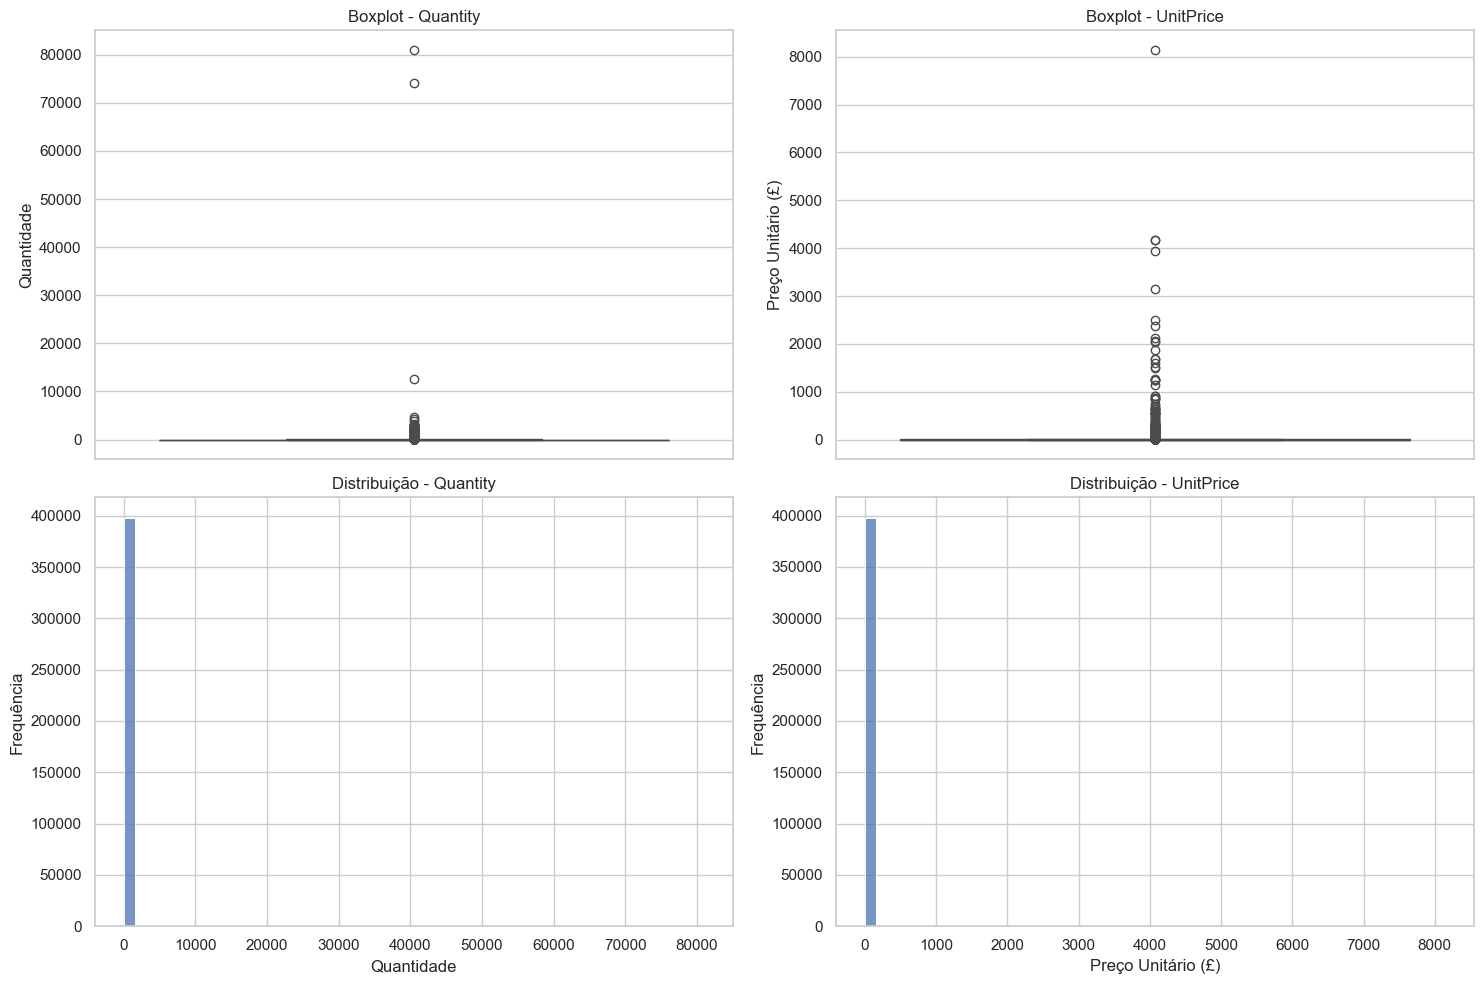

📊 Estatísticas de Quantity:


count   397924.00
mean        13.02
std        180.42
min          1.00
25%          2.00
50%          6.00
75%         12.00
90%         24.00
95%         36.00
99%        120.00
max      80995.00
Name: Quantity, dtype: float64


📊 Estatísticas de UnitPrice:


count   397924.00
mean         3.12
std         22.10
min          0.00
25%          1.25
50%          1.95
75%          3.75
90%          6.35
95%          8.50
99%         14.95
max       8142.75
Name: UnitPrice, dtype: float64

In [8]:
# %% [markdown]
# ### 8. Análise de Outliers em Quantidade e Preço

# %%
# Análise de outliers
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Boxplots
sns.boxplot(data=df_sales, y='Quantity', ax=axes[0,0])
axes[0,0].set_title('Boxplot - Quantity')
axes[0,0].set_ylabel('Quantidade')

sns.boxplot(data=df_sales, y='UnitPrice', ax=axes[0,1])
axes[0,1].set_title('Boxplot - UnitPrice')
axes[0,1].set_ylabel('Preço Unitário (£)')

# Histogramas
sns.histplot(data=df_sales, x='Quantity', bins=50, ax=axes[1,0])
axes[1,0].set_title('Distribuição - Quantity')
axes[1,0].set_xlabel('Quantidade')
axes[1,0].set_ylabel('Frequência')

sns.histplot(data=df_sales, x='UnitPrice', bins=50, ax=axes[1,1])
axes[1,1].set_title('Distribuição - UnitPrice')
axes[1,1].set_xlabel('Preço Unitário (£)')
axes[1,1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

# %%
# Estatísticas detalhadas
print("📊 Estatísticas de Quantity:")
display(df_sales['Quantity'].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

print("\n📊 Estatísticas de UnitPrice:")
display(df_sales['UnitPrice'].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

📅 Vendas por mês:


Num_Transacoes  Quantidade_Total  Valor_Total
Year Month                                               
2010 12               1400            312280    572713.89
2011 1                 987            349147    569445.04
     2                 998            265638    447137.35
     3                1321            348544    595500.76
     4                1149            292225    469200.36
     5                1555            373685    678594.56
     6                1393            363699    661213.69
     7                1331            369432    600091.01
     8                1281            398938    645343.90
     9                1756            544899    952838.38
     10               1929            593908   1039318.79
     11               2658            681888   1161817.38
     12                778            287413    518192.79

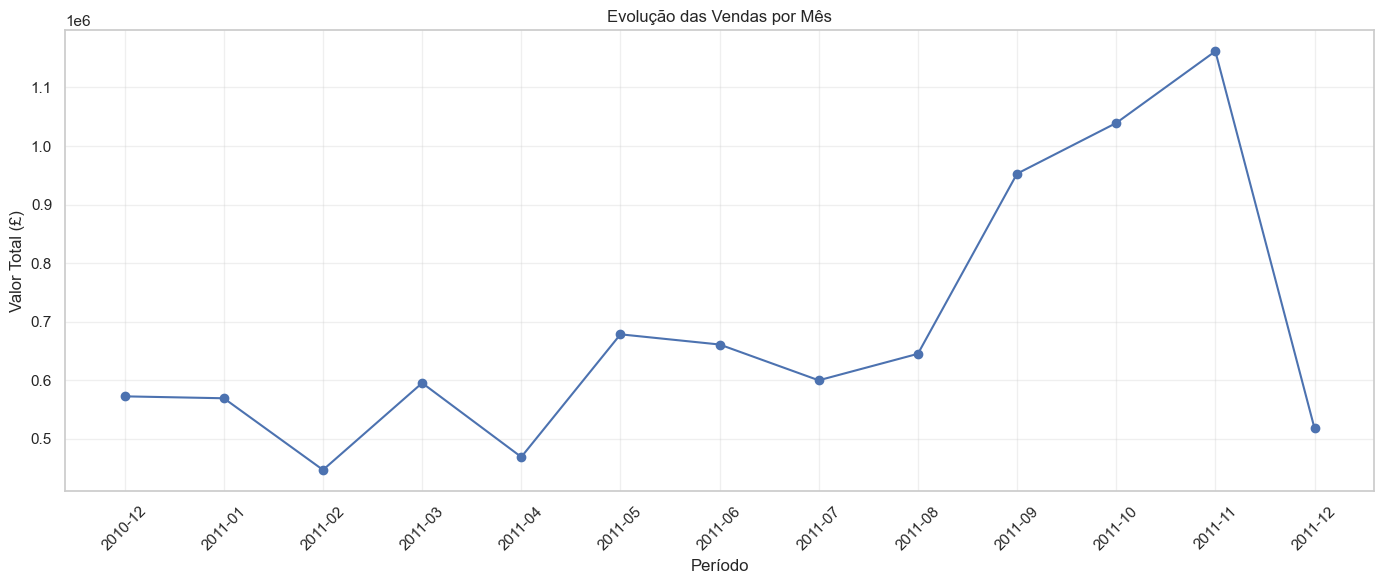

In [9]:
# %% [markdown]
# ### 9. Análise Temporal
# 
# Vamos criar features de data para análise de sazonalidade.

# %%
# Extrair features de data
df_sales['Year'] = df_sales['InvoiceDate'].dt.year
df_sales['Month'] = df_sales['InvoiceDate'].dt.month
df_sales['Day'] = df_sales['InvoiceDate'].dt.day
df_sales['DayOfWeek'] = df_sales['InvoiceDate'].dt.dayofweek
df_sales['Hour'] = df_sales['InvoiceDate'].dt.hour
df_sales['Weekend'] = df_sales['DayOfWeek'].isin([5, 6])

# %%
# Vendas por mês
monthly_sales = df_sales.groupby(['Year', 'Month']).agg({
    'InvoiceNo': 'nunique',
    'Quantity': 'sum',
    'UnitPrice': lambda x: (x * df_sales.loc[x.index, 'Quantity']).sum()
}).round(2)

monthly_sales.columns = ['Num_Transacoes', 'Quantidade_Total', 'Valor_Total']
print("📅 Vendas por mês:")
display(monthly_sales)

# %%
# Visualização - Vendas por mês
plt.figure(figsize=(14, 6))
monthly_sales['Valor_Total'].plot(kind='line', marker='o')
plt.title('Evolução das Vendas por Mês')
plt.xlabel('Período')
plt.ylabel('Valor Total (£)')
plt.grid(True, alpha=0.3)
plt.xticks(range(len(monthly_sales)), 
           [f"{y}-{m:02d}" for y, m in monthly_sales.index], 
           rotation=45)
plt.tight_layout()
plt.show()

🌍 Top 10 países por valor de venda:


,Clientes_Unicos,Transacoes,Quantidade_Total,Valor_Total
Country,,,,
United Kingdom,3921,16649,4269472,7308391.55
Netherlands,9,95,200937,285446.34
EIRE,3,260,140525,265545.90
Germany,94,457,119263,228867.14
France,87,389,111472,209024.05
Australia,9,57,84209,138521.31
Spain,30,90,27951,61577.11
Switzerland,21,51,30083,56443.95
Belgium,25,98,23237,41196.34


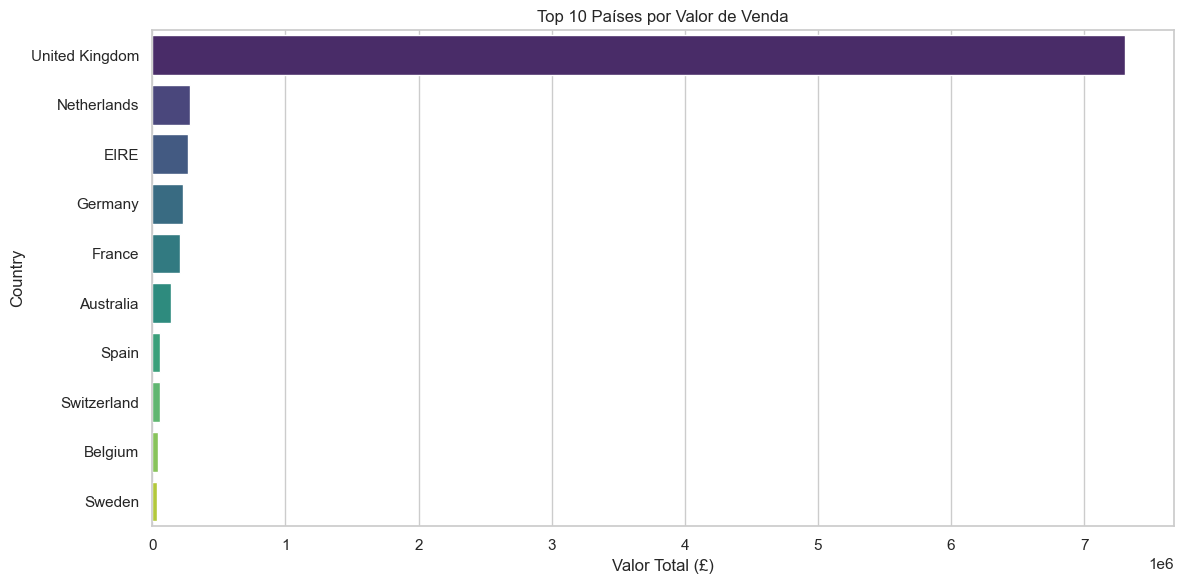

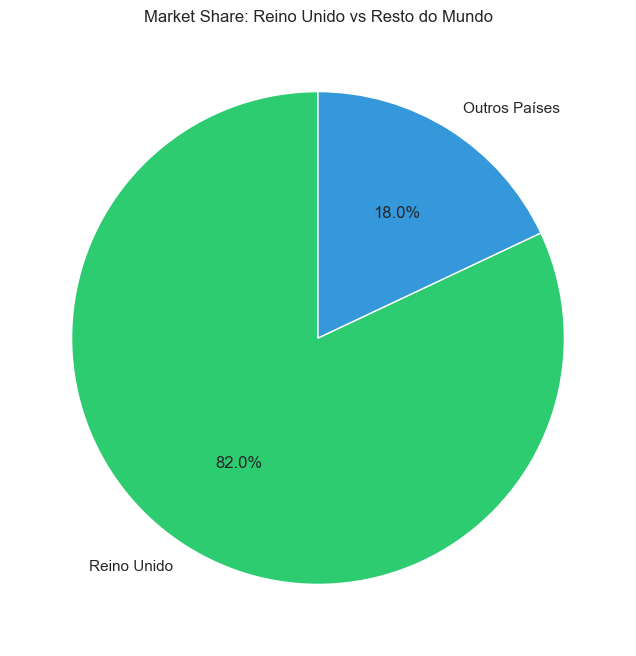

In [10]:
# %% [markdown]
# ### 10. Análise por País

# %%
# Vendas por país
country_analysis = df_sales.groupby('Country').agg({
    'CustomerID': 'nunique',
    'InvoiceNo': 'nunique',
    'Quantity': 'sum',
    'UnitPrice': lambda x: (x * df_sales.loc[x.index, 'Quantity']).sum()
}).round(2)

country_analysis.columns = ['Clientes_Unicos', 'Transacoes', 'Quantidade_Total', 'Valor_Total']
country_analysis = country_analysis.sort_values('Valor_Total', ascending=False)

print("🌍 Top 10 países por valor de venda:")
display(country_analysis.head(10))

# %%
# Visualização - Top 10 países
plt.figure(figsize=(12, 6))
top_countries = country_analysis.head(10)
sns.barplot(data=top_countries.reset_index(), 
            x='Valor_Total', 
            y='Country',
            palette='viridis')
plt.title('Top 10 Países por Valor de Venda')
plt.xlabel('Valor Total (£)')
plt.tight_layout()
plt.show()

# %%
# Market share - UK vs Resto do Mundo
uk_sales = country_analysis.loc['United Kingdom', 'Valor_Total']
other_sales = country_analysis.drop('United Kingdom')['Valor_Total'].sum()

plt.figure(figsize=(8, 8))
plt.pie([uk_sales, other_sales], 
        labels=['Reino Unido', 'Outros Países'],
        autopct='%1.1f%%',
        colors=['#2ecc71', '#3498db'],
        startangle=90)
plt.title('Market Share: Reino Unido vs Resto do Mundo')
plt.show()

🏆 Top 10 produtos mais vendidos (por quantidade):


,,Quantidade_Total,Preco_Medio,Num_Transacoes
StockCode,Description,,,
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,1
23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,1.22,195
84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415,0.29,472
85099B,JUMBO BAG RED RETROSPOT,46181,2.02,1600
85123A,WHITE HANGING HEART T-LIGHT HOLDER,36725,2.89,1971
84879,ASSORTED COLOUR BIRD ORNAMENT,35362,1.68,1375
21212,PACK OF 72 RETROSPOT CAKE CASES,33693,0.55,1029
22197,POPCORN HOLDER,30931,0.84,632
23084,RABBIT NIGHT LIGHT,27202,2.01,801



💰 Top 10 produtos por receita:


,,Quantidade_Total,Preco_Medio,Num_Transacoes,Receita_Total
StockCode,Description,,,,
M,Manual,7179,171.66,258,1232347.14
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,1,168469.60
22423,REGENCY CAKESTAND 3 TIER,12412,12.48,1704,154901.76
85123A,WHITE HANGING HEART T-LIGHT HOLDER,36725,2.89,1971,106135.25
POST,POSTAGE,3120,31.57,1099,98498.40
23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,1.22,195,95057.52
85099B,JUMBO BAG RED RETROSPOT,46181,2.02,1600,93285.62
47566,PARTY BUNTING,15295,4.87,1380,74486.65
84879,ASSORTED COLOUR BIRD ORNAMENT,35362,1.68,1375,59408.16


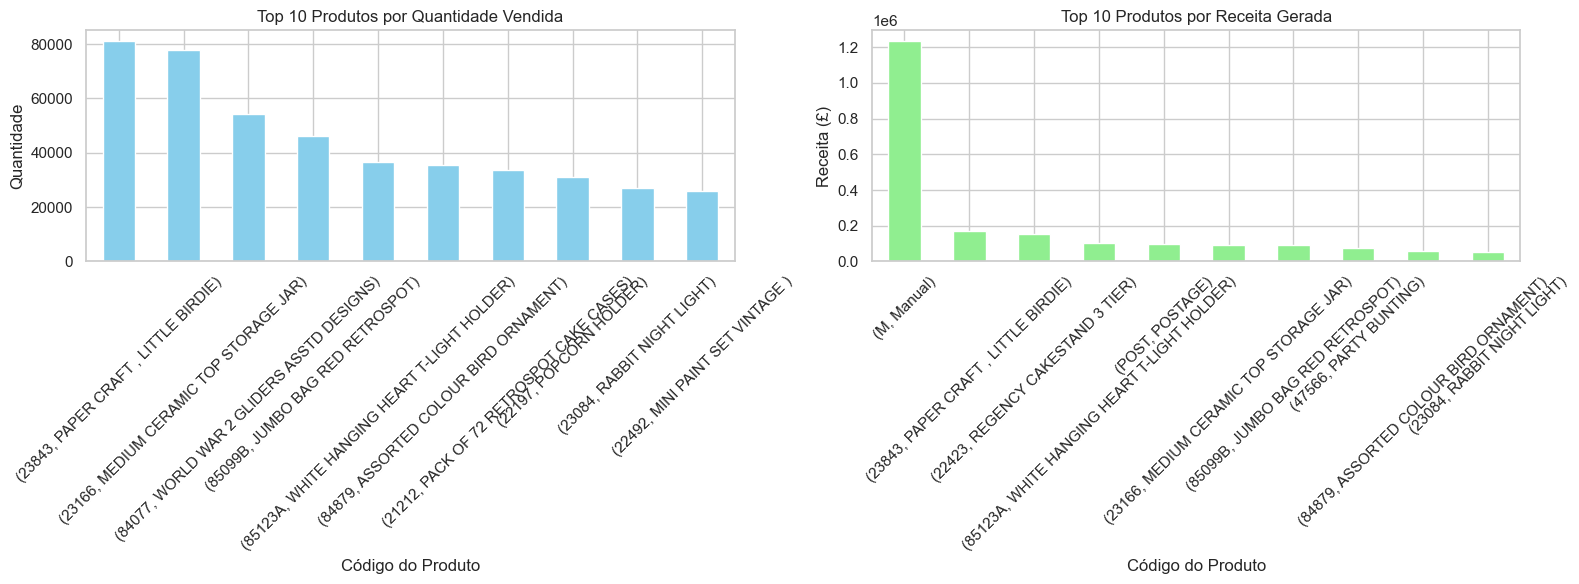

In [11]:
# %% [markdown]
# ### 11. Análise de Produtos

# %%
# Top produtos mais vendidos
top_products = df_sales.groupby(['StockCode', 'Description']).agg({
    'Quantity': 'sum',
    'UnitPrice': 'mean',
    'InvoiceNo': 'nunique'
}).round(2)

top_products.columns = ['Quantidade_Total', 'Preco_Medio', 'Num_Transacoes']
top_products = top_products.sort_values('Quantidade_Total', ascending=False)

print("🏆 Top 10 produtos mais vendidos (por quantidade):")
display(top_products.head(10))

# %%
# Top produtos por receita
top_products['Receita_Total'] = top_products['Quantidade_Total'] * top_products['Preco_Medio']
top_revenue = top_products.sort_values('Receita_Total', ascending=False)

print("\n💰 Top 10 produtos por receita:")
display(top_revenue.head(10))

# %%
# Visualização - Top produtos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Por quantidade
top_products.head(10)['Quantidade_Total'].plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Top 10 Produtos por Quantidade Vendida')
axes[0].set_xlabel('Código do Produto')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=45)

# Por receita
top_revenue.head(10)['Receita_Total'].plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Top 10 Produtos por Receita Gerada')
axes[1].set_xlabel('Código do Produto')
axes[1].set_ylabel('Receita (£)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [12]:
# %% [markdown]
# ### 12. Salvando os Dados Limpos para as Próximas Etapas

# %%
# Salvar dados limpos
output_path = '../data/processed/online_retail_clean.csv'
df_sales.to_csv(output_path, index=False)
print(f"✅ Dados limpos salvos em: {output_path}")
print(f"📊 Shape final: {df_sales.shape}")
print(f"📅 Período: {df_sales['InvoiceDate'].min()} a {df_sales['InvoiceDate'].max()}")
print(f"👥 Clientes únicos: {df_sales['CustomerID'].nunique()}")
print(f"🧾 Transações únicas: {df_sales['InvoiceNo'].nunique()}")
print(f"🏷️ Produtos únicos: {df_sales['StockCode'].nunique()}")
print(f"🌍 Países: {df_sales['Country'].nunique()}")

✅ Dados limpos salvos em: ../data/processed/online_retail_clean.csv
📊 Shape final: (397924, 16)
📅 Período: 2010-12-01 08:26:00 a 2011-12-09 12:50:00
👥 Clientes únicos: 4339
🧾 Transações únicas: 18536
🏷️ Produtos únicos: 3665
🌍 Países: 37


In [13]:
# %% [markdown]
# ### 13. Resumo da Análise Exploratória
# 
# **Principais descobertas:**
# 
# 1. **Dados Faltantes:** 
#    - `CustomerID` tem ~25% de valores nulos - removidos para análise de clientes
#    - `Description` tem poucos nulos (~0.3%)
# 
# 2. **Cancelamentos:** 
#    - ~2% das transações são cancelamentos - removidos para análise de vendas
# 
# 3. **Distribuição dos Dados:**
#    - Grande concentração de vendas no Reino Unido (>80%)
#    - Alta sazonalidade com picos em novembro (Black Friday?)
#    - Presença de outliers em quantidade e preço
# 
# 4. **Qualidade dos Dados:**
#    - Dados consistentes após limpeza
#    - Prontos para engenharia de features (RFM)
# 
# **Próximos passos:**
# - **Notebook 02:** Feature Engineering - Criação das métricas RFM
# - **Notebook 03:** Aplicação de algoritmos de clusterização
# - **Notebook 04:** Avaliação e interpretação dos clusters

# %%
print("✅ EDA concluída com sucesso!")
print("🚀 Próximo passo: Notebook 02 - Feature Engineering (RFM)")

✅ EDA concluída com sucesso!
🚀 Próximo passo: Notebook 02 - Feature Engineering (RFM)
